# Load Sentinel-3 data from the Planetary Computer STAC catalog

This notebook shows an example how to load Sentinel-3 data from the [Planetary Computer STAC API](https://planetarycomputer.microsoft.com/catalog).

### Setup
In order to run this notebook you may install [`xcube_stac`](https://github.com/xcube-dev/xcube-stac), following the [README](../../README.md).

Now, we first import everything we need:

In [1]:
%%time
import xarray as xr
import matplotlib.pyplot as plt
from xcube.core.store import new_data_store, get_data_store_params_schema

CPU times: user 3.97 s, sys: 640 ms, total: 4.61 s
Wall time: 4.67 s


In [2]:
xr.set_options(display_expand_attrs=False)

There are two [data stores](https://xcube.readthedocs.io/en/latest/dataaccess.html#data-store-framework) available for the [CDSE STAC API](https://browser.stac.dataspace.copernicus.eu/?language=en):

- **`stac-pc-ardc`**: Allows you to open multiple STAC items and assemble them into a 3D spatiotemporal data cube.
- **`stac-pc`**: Enables you to open individual STAC items.

---
## Data store to access spatiotemporal anaylsis-ready data cubes 

In the following, we will first demonstrate how to use the `stac-cdse-ardc` store. To view the parameters to initialize the data store instance, execute the following cell. 

> **Note:**  
> Access requires your S3 `key` and `secret`.

In [3]:
%%time
store_params = get_data_store_params_schema("stac-pc-ardc")
store_params

CPU times: user 420 ms, sys: 95.8 ms, total: 516 ms
Wall time: 646 ms


In [4]:
%%time
store = new_data_store("stac-pc-ardc")

CPU times: user 14 ms, sys: 3.35 ms, total: 17.4 ms
Wall time: 205 ms


The following cell shows the available data IDs for the analysis-ready datacube mode. The data IDs point to a STAC collections.

In [5]:
%%time
data_ids = store.list_data_ids()
data_ids

CPU times: user 17 μs, sys: 3 μs, total: 20 μs
Wall time: 22.6 μs


['sentinel-2-l2a',
 'sentinel-3-synergy-syn-l2-netcdf',
 'sentinel-3-slstr-lst-l2-netcdf']

Below, the parameters for the `open_data` method can be viewed for aspecific data ID.

In [6]:
%%time
open_params = store.get_open_data_params_schema("sentinel-3-synergy-syn-l2-netcdf")
open_params

CPU times: user 38 μs, sys: 6 μs, total: 44 μs
Wall time: 47.7 μs


The store supports the collection `"sentinel-3-synergy-syn-l2-netcdf"`, from which ARDC can be built as shown in the next cell. 

In [7]:
%%time
ds = store.open_data(
    data_id="sentinel-3-synergy-syn-l2-netcdf",
    bbox=[8, 52, 12, 55],
    time_range=["2020-07-31", "2020-08-01"],
    spatial_res=250 / 111320,  # meter in degree
    crs="EPSG:4326",
    asset_names=["syn-oa01-reflectance", "syn-oa02-reflectance"],
)
ds

CPU times: user 14.6 s, sys: 12.8 s, total: 27.4 s
Wall time: 1min 26s


<xarray.Dataset> Size: 152MB
Dimensions:       (time: 2, lat: 1336, lon: 1782)
Coordinates:
  * time          (time) datetime64[ns] 16B 2020-07-31T09:46:20.748357 2020-0...
  * lat           (lat) float64 11kB 55.0 55.0 54.99 54.99 ... 52.01 52.0 52.0
  * lon           (lon) float64 14kB 8.001 8.003 8.006 8.008 ... 12.0 12.0 12.0
    spatial_ref   int64 8B 0
Data variables:
    SDR_Oa01      (time, lat, lon) float64 38MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    SDR_Oa01_err  (time, lat, lon) float64 38MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    SDR_Oa02      (time, lat, lon) float64 38MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    SDR_Oa02_err  (time, lat, lon) float64 38MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
Attributes: (17)

We can plot the spectral band 0 from the  OLCI Instrument as an example.

CPU times: user 4.37 s, sys: 2.64 s, total: 7.01 s
Wall time: 10.8 s


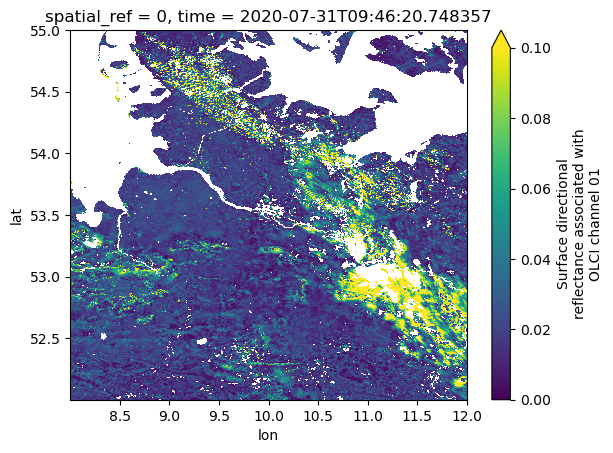

In [8]:
%%time
ds.SDR_Oa01.isel(time=-2).plot(vmin=0.0, vmax=0.1)

Next, we retrieve ARDC from the Sentinel-3 SLSTR Land Surface Temperature collection (`"sentinel-3-slstr-lst-l2-netcdf"`).

In [9]:
%%time
ds = store.open_data(
    data_id="sentinel-3-slstr-lst-l2-netcdf",
    bbox=[8, 52, 12, 55],
    time_range=["2020-07-31", "2020-08-01"],
    spatial_res=250 / 111320,  # meter in degree
    crs="EPSG:4326",
)
ds

CPU times: user 1min 25s, sys: 30.2 s, total: 1min 55s
Wall time: 2min 19s


<xarray.Dataset> Size: 86MB
Dimensions:      (time: 4, lat: 1336, lon: 1782)
Coordinates:
  * time         (time) datetime64[ns] 32B 2020-07-31T09:46:20.748236 ... 202...
  * lat          (lat) float64 11kB 55.0 55.0 54.99 54.99 ... 52.01 52.0 52.0
  * lon          (lon) float64 14kB 8.001 8.003 8.006 8.008 ... 12.0 12.0 12.0
    spatial_ref  int64 8B 0
Data variables:
    mask         (time, lat, lon) uint8 10MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
    LST          (time, lat, lon) float64 76MB dask.array<chunksize=(1, 1336, 1782), meta=np.ndarray>
Attributes: (19)

CPU times: user 9.3 s, sys: 2.7 s, total: 12 s
Wall time: 8.35 s


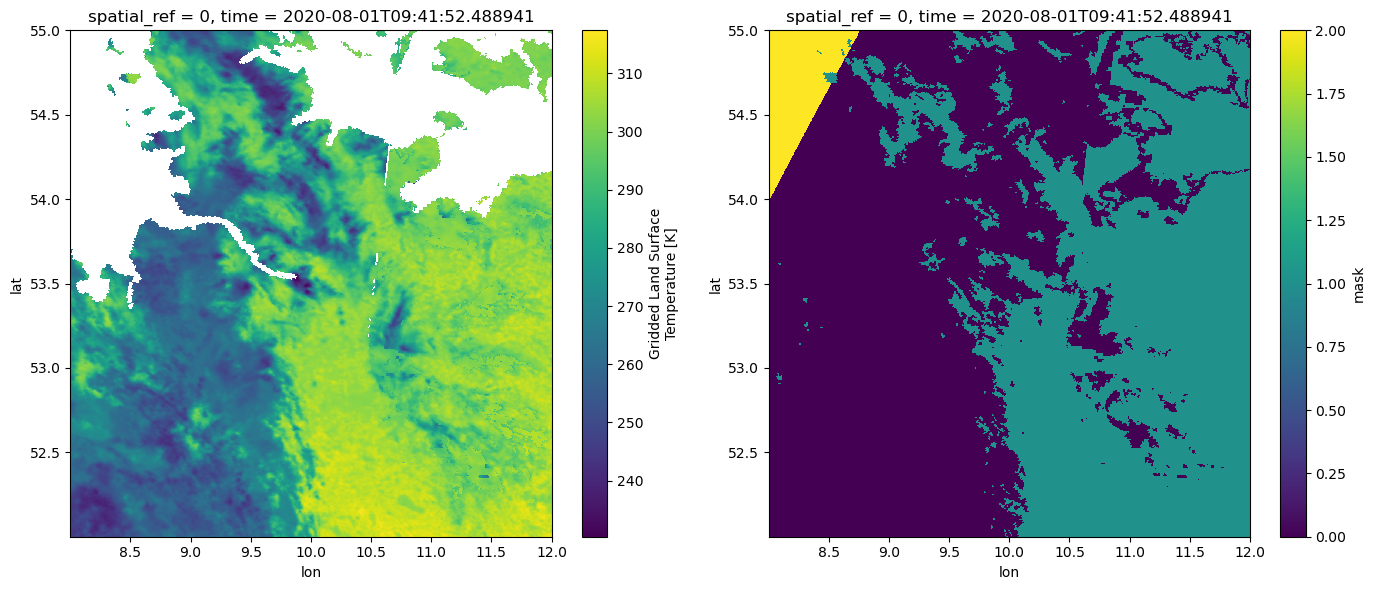

In [10]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ds.LST.isel(time=-2).plot(ax=ax[0])
ds.mask.isel(time=-2).plot(ax=ax[1])
plt.tight_layout()

----
## Data store to access single observations
Now, we initiate the data store to access each STAC item representing one observation tile. 

In [11]:
%%time
store_params = get_data_store_params_schema("stac-pc")
store_params

CPU times: user 39 μs, sys: 16 μs, total: 55 μs
Wall time: 66 μs


To initialize the CDSE STAC data store, execute the following cell.

In [12]:
%%time
store = new_data_store("stac-pc")

CPU times: user 23.4 ms, sys: 11.1 ms, total: 34.5 ms
Wall time: 434 ms


We can search for Sentinel-3 SYN products, as shwon below:

In [13]:
search_params = store.get_search_params_schema()
search_params

In [14]:
descriptors = list(
    store.search_data(
        collections=["sentinel-3-synergy-syn-l2-netcdf"],
        bbox=[9, 47, 10, 48],
        time_range=["2020-07-01", "2020-07-05"],
    )
)
[d.to_dict() for d in descriptors]

[{'data_id': 'collections/sentinel-3-synergy-syn-l2-netcdf/items/S3A_SY_2_SYN_20200705T094658_20200705T094958_0180_060_136_2160',
  'data_type': 'dataset',
  'bbox': [-1.5134, 39.5428, 18.4889, 52.4499],
  'time_range': ('2020-07-05T09:46:57.969790Z',
   '2020-07-05T09:49:57.969790Z')},
 {'data_id': 'collections/sentinel-3-synergy-syn-l2-netcdf/items/S3B_SY_2_SYN_20200705T090731_20200705T091031_0179_040_378_2160',
  'data_type': 'dataset',
  'bbox': [8.3152, 39.5562, 28.3241, 52.4659],
  'time_range': ('2020-07-05T09:07:31.314318Z',
   '2020-07-05T09:10:31.314318Z')},
 {'data_id': 'collections/sentinel-3-synergy-syn-l2-netcdf/items/S3A_SY_2_SYN_20200704T101309_20200704T101609_0179_060_122_2160',
  'data_type': 'dataset',
  'bbox': [-8.0581, 39.5416, 11.943, 52.4497],
  'time_range': ('2020-07-04T10:13:08.862747Z',
   '2020-07-04T10:16:08.862747Z')},
 {'data_id': 'collections/sentinel-3-synergy-syn-l2-netcdf/items/S3B_SY_2_SYN_20200704T093342_20200704T093642_0179_040_364_2160',
  'data_

Below, the parameters for the `open_data` method can be viewed.

In [15]:
open_params = store.get_open_data_params_schema(data_id=descriptors[0].data_id)
open_params

We can now open the data set associated with the data ID. Note that first we do not apply any rectification. Thus the data is shown on the irregular native grid. 

In [16]:
%%time
ds = store.open_data(descriptors[0].data_id, apply_rectification=False, add_error_bands=False)
ds

CPU times: user 650 ms, sys: 240 ms, total: 890 ms
Wall time: 5.13 s


<xarray.Dataset> Size: 4GB
Dimensions:   (y: 4091, x: 4865)
Coordinates:
    lat       (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    lon       (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables: (12/26)
    SDR_S1N   (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S1O   (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S2N   (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S2O   (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S3N   (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S3O   (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    ...        ...
    SDR_Oa11  (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa12  (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa16  (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa17  (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa18  (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa21  (y, x) float64 159MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
Attributes: (14)

CPU times: user 2.2 s, sys: 1.73 s, total: 3.92 s
Wall time: 16.1 s


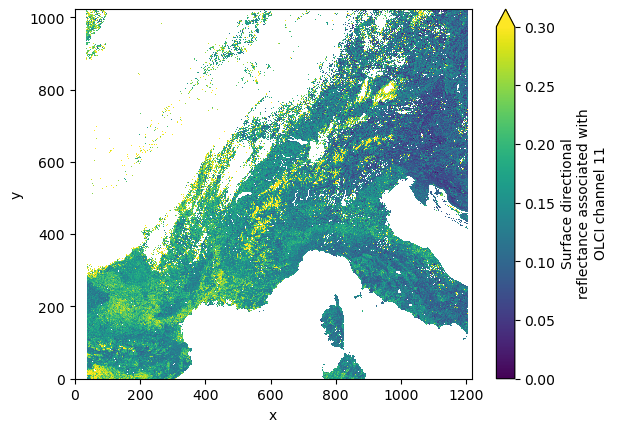

In [17]:
%%time
ds.SDR_Oa11[::4, ::4].plot(vmax=0.3, vmin=0.)

In the next step we show the dataset on a regular grid, where the [xcube's rectification algorithm](https://xcube.readthedocs.io/en/latest/rectify.html) is applied. Note that showing the data on a regular grid is the default. 

In [18]:
%%time
ds = store.open_data(descriptors[0].data_id)
ds

CPU times: user 3.9 s, sys: 2.04 s, total: 5.94 s
Wall time: 17.8 s


<xarray.Dataset> Size: 12GB
Dimensions:       (lon: 5787, lat: 5071)
Coordinates:
  * lon           (lon) float64 46kB -1.513 -1.51 -1.506 ... 18.48 18.48 18.49
  * lat           (lat) float64 41kB 52.45 52.45 52.44 ... 39.55 39.55 39.54
    spatial_ref   int64 8B 0
Data variables: (12/52)
    SDR_S1N       (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S1N_err   (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S1O       (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S1O_err   (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S2N       (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_S2N_err   (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    ...            ...
    SDR_Oa17      (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa17_err  (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa18      (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa18_err  (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa21      (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
    SDR_Oa21_err  (lat, lon) float64 235MB dask.array<chunksize=(4091, 4865), meta=np.ndarray>
Attributes: (14)

CPU times: user 44.3 s, sys: 16.4 s, total: 1min
Wall time: 23 s


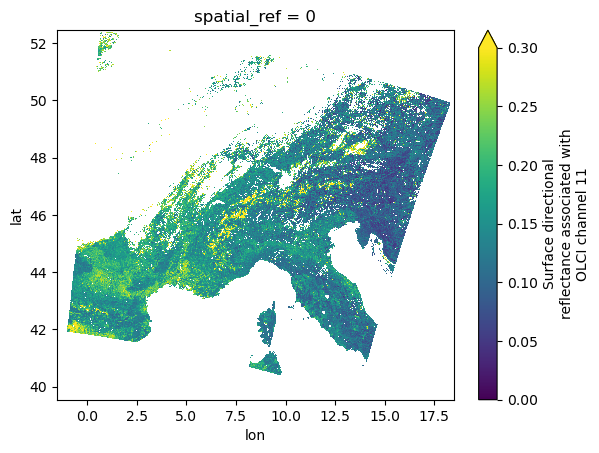

In [19]:
%%time
ds.SDR_Oa11[::4, ::4].plot(vmin=0., vmax=0.3)

The same we can do the Sentinel-3 SLSTR Land Surface Temperature

In [20]:
%%time
descriptors = list(
    store.search_data(
        collections=["sentinel-3-slstr-lst-l2-netcdf"],
        bbox=[9, 47, 10, 48],
        time_range=["2020-07-01", "2020-07-05"],
    )
)
[d.to_dict() for d in descriptors]

CPU times: user 527 ms, sys: 389 ms, total: 916 ms
Wall time: 8.76 s


[{'data_id': 'collections/sentinel-3-slstr-lst-l2-netcdf/items/S3A_SL_2_LST_20200705T210953_20200705T211253_0180_060_143_0720',
  'data_type': 'dataset',
  'bbox': [-6.5275, 41.1064, 16.7602, 54.486],
  'time_range': ('2020-07-05T21:09:52.587459Z',
   '2020-07-05T21:12:52.587459Z')},
 {'data_id': 'collections/sentinel-3-slstr-lst-l2-netcdf/items/S3B_SL_2_LST_20200705T203026_20200705T203326_0179_040_385_0720',
  'data_type': 'dataset',
  'bbox': [3.286, 41.097, 26.5757, 54.4859],
  'time_range': ('2020-07-05T20:30:25.939839Z',
   '2020-07-05T20:33:25.939839Z')},
 {'data_id': 'collections/sentinel-3-slstr-lst-l2-netcdf/items/S3A_SL_2_LST_20200705T094658_20200705T094958_0179_060_136_2160',
  'data_type': 'dataset',
  'bbox': [-1.7734, 39.1027, 20.6113, 52.4606],
  'time_range': ('2020-07-05T09:46:57.969633Z',
   '2020-07-05T09:49:57.969633Z')},
 {'data_id': 'collections/sentinel-3-slstr-lst-l2-netcdf/items/S3B_SL_2_LST_20200705T090731_20200705T091031_0179_040_378_2160',
  'data_type': 'da

In [21]:
open_params = store.get_open_data_params_schema(data_id=descriptors[0].data_id)
open_params

In [22]:
%%time
ds = store.open_data(descriptors[2].data_id, apply_rectification=False)
ds

CPU times: user 894 ms, sys: 440 ms, total: 1.33 s
Wall time: 2.84 s


<xarray.Dataset> Size: 45MB
Dimensions:  (y: 1200, x: 1500)
Coordinates:
    lat      (y, x) float64 14MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    lon      (y, x) float64 14MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
Dimensions without coordinates: y, x
Data variables:
    LST      (y, x) float64 14MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    mask     (y, x) uint8 2MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
Attributes: (16)

CPU times: user 2.22 s, sys: 755 ms, total: 2.97 s
Wall time: 6.04 s


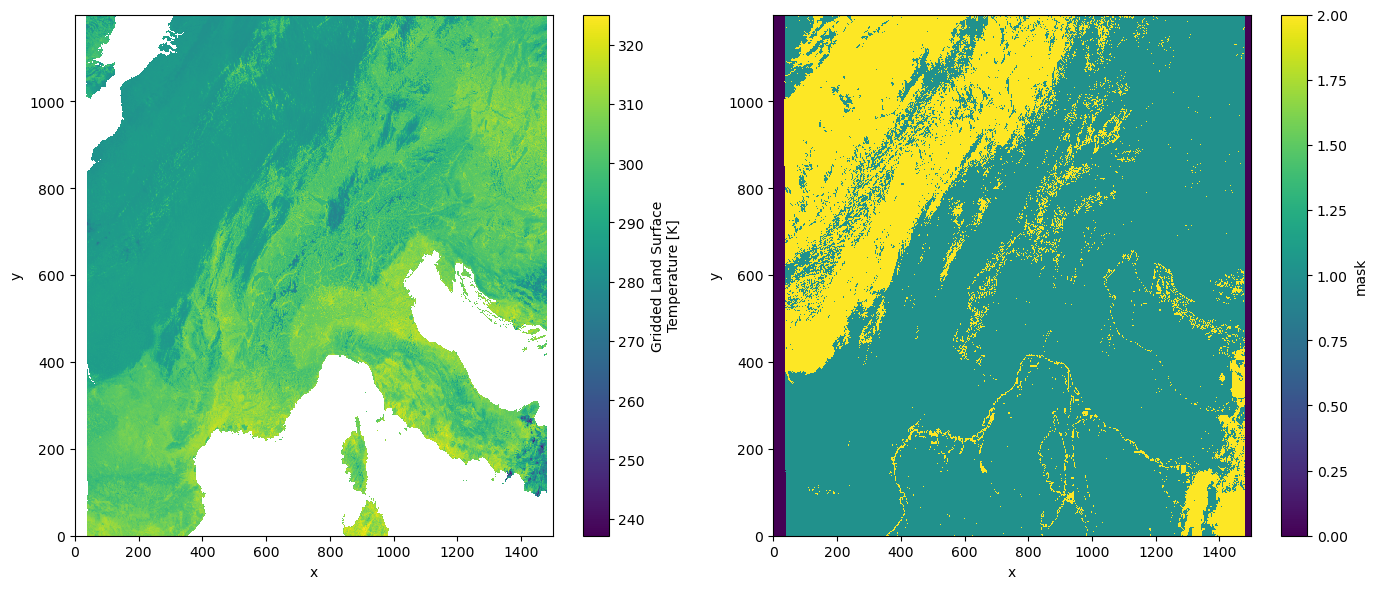

In [23]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ds.LST.plot(ax=ax[0])
ds.mask.plot(ax=ax[1])
plt.tight_layout()

In [24]:
%%time
ds = store.open_data(descriptors[2].data_id)
ds

CPU times: user 3.4 s, sys: 984 ms, total: 4.39 s
Wall time: 3.18 s


<xarray.Dataset> Size: 25MB
Dimensions:      (lon: 1760, lat: 1546)
Coordinates:
  * lon          (lon) float64 14kB -1.773 -1.761 -1.748 ... 20.58 20.59 20.61
  * lat          (lat) float64 12kB 52.46 52.45 52.44 52.43 ... 39.12 39.11 39.1
    spatial_ref  int64 8B 0
Data variables:
    LST          (lat, lon) float64 22MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
    mask         (lat, lon) uint8 3MB dask.array<chunksize=(1200, 1500), meta=np.ndarray>
Attributes: (16)

CPU times: user 9.35 s, sys: 1.84 s, total: 11.2 s
Wall time: 4.47 s


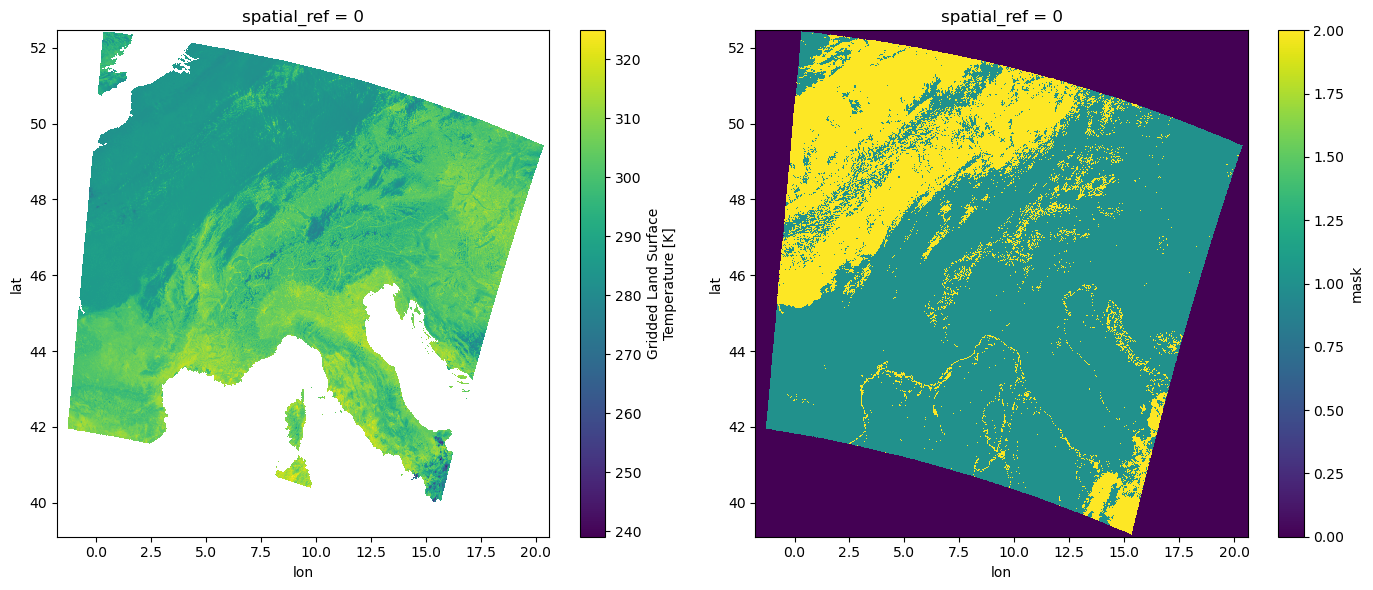

In [25]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ds.LST.plot(ax=ax[0])
ds.mask.plot(ax=ax[1])
plt.tight_layout()